In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,recall_score,precision_score,f1_score

df = pd.read_csv("winequality-red.csv")


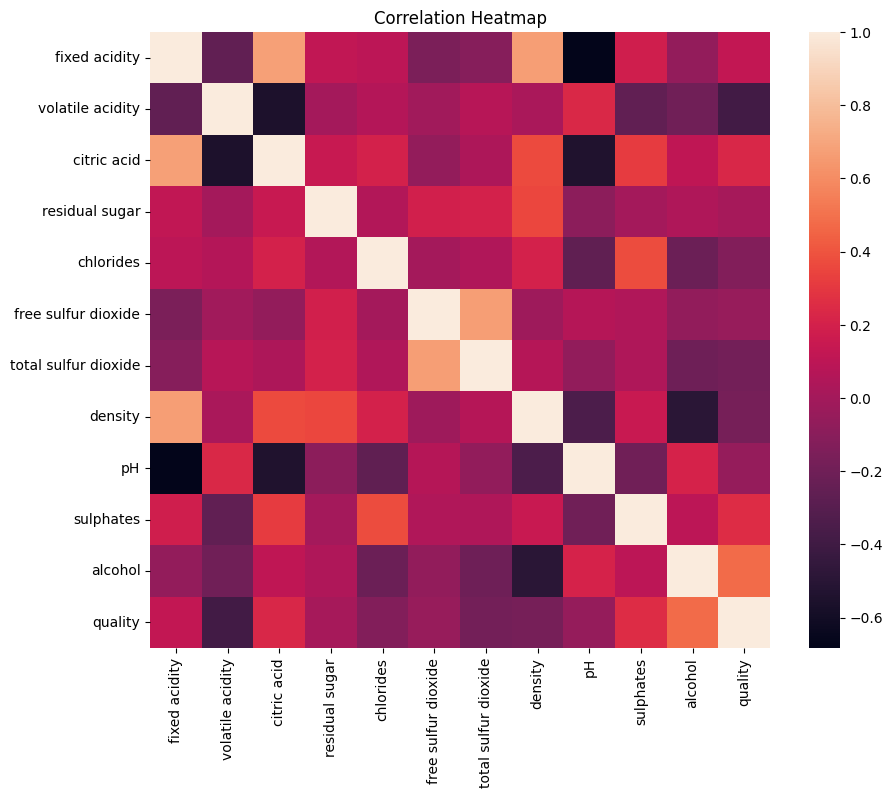

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
df["quality"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)
print(df["quality"].value_counts())

quality
0    1382
1     217
Name: count, dtype: int64


In [13]:
X = df.drop("quality", axis=1)
y = df["quality"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.90625


In [15]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95       273
           1       0.73      0.57      0.64        47

    accuracy                           0.91       320
   macro avg       0.83      0.77      0.79       320
weighted avg       0.90      0.91      0.90       320



In [16]:
print("\nRecall:", recall_score(y_test, y_pred))


Recall: 0.574468085106383


In [17]:
print("\nPrecision:", precision_score(y_test, y_pred))


Precision: 0.7297297297297297


In [18]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[263  10]
 [ 20  27]]


In [19]:
print("\nF1 Score:", f1_score(y_test, y_pred))


F1 Score: 0.6428571428571429


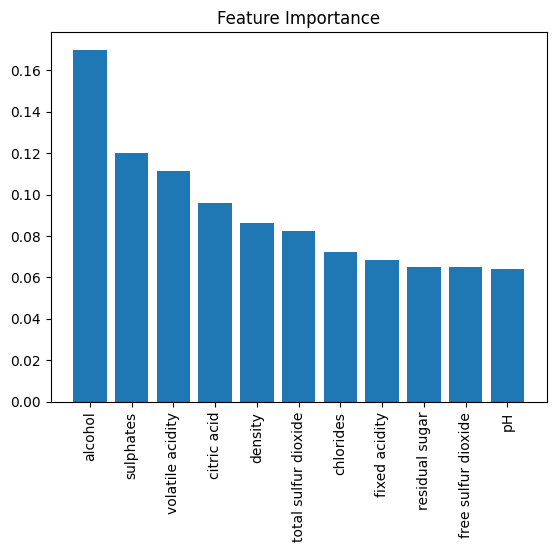

In [20]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure()
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()